05 - Modélisation V1

**Objectif** : Entraîner et optimiser des modèles de classification multi-label

**Pipeline** :
1. Chargement des données preprocessed (train + test)
2. Calcul et sauvegarde des embeddings (all-MiniLM-L6-v2)
3. Calcul et sauvegarde TF-IDF (fit sur train uniquement)
4. Baseline LogisticRegression avec class_weight='balanced'
5. Hyperparameter tuning avec GridSearchCV (Macro-F1)

**Métriques principales** :
- Macro-F1 (score principal pour tuning)
- Micro-F1, FA par label pour information


# A. Imports & Preprocess

### 1. Imports & Configuration


In [ ]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import time
import joblib
from scipy.sparse import save_npz, load_npz, hstack

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    hamming_loss, make_scorer
)
from sklearn.model_selection import GridSearchCV
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Chemins
DATA_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Tags prioritaires
PRIORITY_TAGS = [
    'math', 'graphs', 'strings', 'number theory',
    'trees', 'geometry', 'games', 'probabilities'
]

print("✅ Imports chargés")
print(f"📁 Data directory: {DATA_DIR}")
print(f"📁 Models directory: {MODELS_DIR}")


/app/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports chargés
📁 Data directory: ../data/processed
📁 Models directory: ../models


## 2. Chargement des Données


In [ ]:
print("="*80)
print("CHARGEMENT DES DONNÉES PREPROCESSED")
print("="*80)

# Charger train et test
train_path = DATA_DIR / 'train_preprocessed.parquet'
test_path = DATA_DIR / 'test_preprocessed.parquet'

df_train = pd.read_parquet(train_path)
df_test = pd.read_parquet(test_path)

print(f"\nTrain: {len(df_train):,} samples, {len(df_train.columns)} features")
print(f"Test:  {len(df_test):,} samples, {len(df_test.columns)} features")

# Identifier les colonnes target
target_columns = sorted([col for col in df_train.columns if col.startswith('target_')])
print(f"\nTarget columns: {len(target_columns)}")
for col in target_columns:
    print(f"  - {col}")


CHARGEMENT DES DONNÉES PREPROCESSED

Train: 3,978 samples, 78 features
Test:  995 samples, 78 features

Target columns: 8
  - target_games
  - target_geometry
  - target_graphs
  - target_math
  - target_number theory
  - target_probabilities
  - target_strings
  - target_trees


In [ ]:
# ============================================================================
# REGROUPEMENT DES VARIABLES EXPLICATIVES
# ============================================================================

print("="*80)
print("IDENTIFICATION DES VARIABLES EXPLICATIVES")
print("="*80)

# Features LaTeX numériques (4 features)
features_latex_numeriques = [
    'nb_latex_blocks',
    'nb_latex_symbols',
    'latex_density',
    'latex_symbols_density'
]

# Features LaTeX binaires (toutes les colonnes commençant par 'has_')
features_latex_binaires = [col for col in df_train.columns if col.startswith('has_')]

# Features LaTeX complètes
features_latex = features_latex_numeriques + features_latex_binaires

# Features numériques générales (2 features)
features_numeriques_base = [
    'difficulty',
    'time_limit_seconds'
]

# Features de longueur de texte (pour prob_desc_description_translated)
features_longueur_texte = [
    'prob_desc_description_translated_char_length',
    'prob_desc_description_translated_word_count',
    'prob_desc_description_translated_numeric_ratio',
    'prob_desc_description_translated_latex_ratio'
]

# Features numériques complètes
features_numeriques = features_numeriques_base + features_longueur_texte

# Vérifier la présence et garder uniquement les présentes
features_latex = [f for f in features_latex if f in df_train.columns]
features_numeriques = [f for f in features_numeriques if f in df_train.columns]

features_latex_manquantes = [f for f in (features_latex_numeriques + features_latex_binaires) if f not in df_train.columns]
features_numeriques_manquantes = [f for f in (features_numeriques_base + features_longueur_texte) if f not in df_train.columns]

print(f"\n  Features LaTeX:")
print(f"    Numériques: {len(features_latex_numeriques)}")
print(f"    Binaires:   {len(features_latex_binaires)}")
print(f"    Total:      {len(features_latex)} présentes")

if features_latex_manquantes:
    print(f"    ⚠️  Manquantes: {features_latex_manquantes}")

print(f"\n  Features numériques:")
print(f"    Base:       {len(features_numeriques_base)}")
print(f"    Longueur:   {len(features_longueur_texte)}")
print(f"    Total:      {len(features_numeriques)} présentes")

if features_numeriques_manquantes:
    print(f"    ⚠️  Manquantes: {features_numeriques_manquantes}")

print(f"\n✅ Variables identifiées:")
print(f"  Features LaTeX:      {len(features_latex)} features")
print(f"  Features numériques:  {len(features_numeriques)} features")
print(f"  TOTAL:                {len(features_latex) + len(features_numeriques)} features denses")

print("\n" + "="*80)

IDENTIFICATION DES VARIABLES EXPLICATIVES

  Features LaTeX:
    Numériques: 4
    Binaires:   30
    Total:      34 présentes

  Features numériques:
    Base:       2
    Longueur:   4
    Total:      6 présentes

✅ Variables identifiées:
  Features LaTeX:      34 features
  Features numériques:  6 features
  TOTAL:                40 features denses



## 3. Calcul des Embeddings (all-MiniLM-L6-v2)

Calcul des embeddings sur `prob_desc_description_translated` pour train et test.


In [ ]:
print("="*80)
print("CHARGEMENT / CALCUL DES EMBEDDINGS - all-MiniLM-L6-v2")
print("="*80)

# Chemins des fichiers
embeddings_train_path = DATA_DIR / 'embeddings_train_minilm.npy'
embeddings_test_path = DATA_DIR / 'embeddings_test_minilm.npy'

# Vérifier si les fichiers existent
if embeddings_train_path.exists() and embeddings_test_path.exists():
    print(f"\n[1/1] Chargement des embeddings pré-calculés...")
    embeddings_train = np.load(embeddings_train_path)
    embeddings_test = np.load(embeddings_test_path)
    print(f"  ✅ Train chargé: {embeddings_train.shape}")
    print(f"  ✅ Test chargé:  {embeddings_test.shape}")
    print(f"  Taille: {embeddings_train.nbytes / 1024**2:.2f} MB (train), {embeddings_test.nbytes / 1024**2:.2f} MB (test)")
    print("\n✅ Embeddings chargés depuis fichiers")
else:
    print(f"\n⚠️  Fichiers non trouvés, calcul des embeddings...")
    
    # Colonne texte à utiliser
    text_column = 'prob_desc_description_translated'
    
    # Vérifier que la colonne existe
    assert text_column in df_train.columns, f"Colonne {text_column} manquante dans train"
    assert text_column in df_test.columns, f"Colonne {text_column} manquante dans test"
    
    # Charger le modèle
    print(f"\n[1/4] Chargement du modèle 'sentence-transformers/all-MiniLM-L6-v2'...")
    model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    embedding_dim = model.get_sentence_embedding_dimension()
    print(f"  ✅ Modèle chargé: {embedding_dim} dimensions")
    
    # Extraire les textes
    texts_train = df_train[text_column].fillna('').astype(str).tolist()
    texts_test = df_test[text_column].fillna('').astype(str).tolist()
    
    print(f"\n[2/4] Encoding TRAIN ({len(texts_train):,} documents)...")
    start_time = time.time()
    embeddings_train = model.encode(
        texts_train,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True  # Normalisation L2
    )
    train_time = time.time() - start_time
    print(f"  ✅ Terminé en {train_time:.2f}s ({train_time/60:.2f} min)")
    print(f"  Shape: {embeddings_train.shape}")
    
    print(f"\n[3/4] Encoding TEST ({len(texts_test):,} documents)...")
    start_time = time.time()
    embeddings_test = model.encode(
        texts_test,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    test_time = time.time() - start_time
    print(f"  ✅ Terminé en {test_time:.2f}s ({test_time/60:.2f} min)")
    print(f"  Shape: {embeddings_test.shape}")
    
    # Sauvegarder
    print(f"\n[4/4] Sauvegarde des embeddings...")
    np.save(embeddings_train_path, embeddings_train)
    np.save(embeddings_test_path, embeddings_test)
    
    print(f"  ✅ Train sauvegardé: {embeddings_train_path}")
    print(f"  ✅ Test sauvegardé:  {embeddings_test_path}")
    print(f"  Taille: {embeddings_train.nbytes / 1024**2:.2f} MB (train), {embeddings_test.nbytes / 1024**2:.2f} MB (test)")
    
    print("\n✅ Embeddings calculés et sauvegardés")

print("="*80)


CHARGEMENT / CALCUL DES EMBEDDINGS - all-MiniLM-L6-v2

[1/1] Chargement des embeddings pré-calculés...
  ✅ Train chargé: (3978, 384)
  ✅ Test chargé:  (995, 384)
  Taille: 5.83 MB (train), 1.46 MB (test)

✅ Embeddings chargés depuis fichiers


## 4. Calcul TF-IDF (Fit sur Train uniquement)

⚠️ **CRITIQUE** : Le TF-IDF doit être fitté UNIQUEMENT sur train, puis transformé sur test.

In [ ]:
print("="*80)
print("CHARGEMENT / CALCUL TF-IDF (FIT SUR TRAIN UNIQUEMENT)")
print("="*80)

# Chemins des fichiers
vectorizer_path = DATA_DIR / 'tfidf_vectorizer.pkl'
tfidf_train_path = DATA_DIR / 'X_tfidf_train.npz'
tfidf_test_path = DATA_DIR / 'X_tfidf_test.npz'

# Vérifier si les fichiers existent
if vectorizer_path.exists() and tfidf_train_path.exists() and tfidf_test_path.exists():
    print(f"\n[1/2] Chargement du vectorizer et matrices TF-IDF pré-calculés...")
    vectorizer = joblib.load(vectorizer_path)
    X_tfidf_train = load_npz(tfidf_train_path)
    X_tfidf_test = load_npz(tfidf_test_path)
    print(f"  ✅ Vectorizer chargé: {len(vectorizer.vocabulary_):,} tokens")
    print(f"  ✅ TF-IDF train: {X_tfidf_train.shape}")
    print(f"  ✅ TF-IDF test:  {X_tfidf_test.shape}")
    print("\n✅ TF-IDF chargé depuis fichiers")
else:
    print(f"\n⚠️  Fichiers non trouvés, calcul du TF-IDF...")
    
    # Colonne texte à utiliser (unified_document_without_latex pour TF-IDF)
    text_column_tfidf = 'unified_document_without_latex'
    
    # Vérifier que la colonne existe
    if text_column_tfidf not in df_train.columns:
        print(f"⚠️  Colonne {text_column_tfidf} manquante, utilisation de 'unified_document'")
        text_column_tfidf = 'unified_document'
    
    assert text_column_tfidf in df_train.columns, f"Colonne {text_column_tfidf} manquante"
    
    # Extraire les textes
    texts_train_tfidf = df_train[text_column_tfidf].fillna('').astype(str).tolist()
    texts_test_tfidf = df_test[text_column_tfidf].fillna('').astype(str).tolist()
    
    # Créer le vectorizer
    print(f"\n[1/3] Création du TfidfVectorizer...")
    vectorizer = TfidfVectorizer(
        analyzer='word',
        lowercase=False,  # Déjà en lowercase
        ngram_range=(1, 2),  # Unigrammes + bigrammes
        min_df=2,
        max_df=0.95,
        max_features=5000,  # Limiter pour performance
        sublinear_tf=True,
        norm='l2',
        smooth_idf=True,
        stop_words=None
    )
    
    print(f"  Paramètres:")
    print(f"    - ngram_range: {vectorizer.ngram_range}")
    print(f"    - min_df: {vectorizer.min_df}")
    print(f"    - max_df: {vectorizer.max_df}")
    print(f"    - max_features: {vectorizer.max_features}")
    
    # FIT uniquement sur TRAIN
    print(f"\n[2/3] Fit sur TRAIN ({len(texts_train_tfidf):,} documents)...")
    start_time = time.time()
    X_tfidf_train = vectorizer.fit_transform(texts_train_tfidf)
    fit_time = time.time() - start_time
    print(f"  ✅ Terminé en {fit_time:.2f}s")
    print(f"  Vocabulaire: {len(vectorizer.vocabulary_):,} tokens")
    print(f"  Shape: {X_tfidf_train.shape}")
    
    # TRANSFORM sur TEST (sans refit)
    print(f"\n[3/3] Transform sur TEST ({len(texts_test_tfidf):,} documents)...")
    start_time = time.time()
    X_tfidf_test = vectorizer.transform(texts_test_tfidf)
    transform_time = time.time() - start_time
    print(f"  ✅ Terminé en {transform_time:.2f}s")
    print(f"  Shape: {X_tfidf_test.shape}")
    
    # Vérification
    assert X_tfidf_train.shape[1] == X_tfidf_test.shape[1], "Vocabulaire différent!"
    print(f"  ✅ Vocabulaire identique: {X_tfidf_train.shape[1]:,} features")
    
    # Sauvegarder le vectorizer et les matrices
    print(f"\n💾 Sauvegarde...")
    joblib.dump(vectorizer, vectorizer_path)
    save_npz(tfidf_train_path, X_tfidf_train)
    save_npz(tfidf_test_path, X_tfidf_test)
    
    print(f"  ✅ Vectorizer: {vectorizer_path}")
    print(f"  ✅ TF-IDF train: {tfidf_train_path}")
    print(f"  ✅ TF-IDF test:  {tfidf_test_path}")
    
    print("\n✅ TF-IDF calculé et sauvegardé")

print("="*80)


CHARGEMENT / CALCUL TF-IDF (FIT SUR TRAIN UNIQUEMENT)

[1/2] Chargement du vectorizer et matrices TF-IDF pré-calculés...
  ✅ Vectorizer chargé: 5,000 tokens
  ✅ TF-IDF train: (3978, 5000)
  ✅ TF-IDF test:  (995, 5000)

✅ TF-IDF chargé depuis fichiers


## 5. Construction Features Complètes (TF-IDF + Embeddings + Denses)

Construction de toutes les features combinées pour la modélisation.


In [ ]:
# ============================================================================
# CONSTRUCTION DES FEATURES COMPLÈTES
# ============================================================================

print("="*80)
print("CONSTRUCTION DES FEATURES COMPLÈTES")
print("="*80)

# Extraire les features denses
X_dense_train = df_train[features_numeriques + features_latex].values
X_dense_test = df_test[features_numeriques + features_latex].values

print(f"\n[1/4] Features denses:")
print(f"  Train: {X_dense_train.shape}")
print(f"  Test:  {X_dense_test.shape}")

# Vérifier NaN (normalement déjà imputés dans preprocessing)
n_nan_train = np.isnan(X_dense_train).sum()
n_nan_test = np.isnan(X_dense_test).sum()
print(f"  NaN train: {n_nan_train}")
print(f"  NaN test:  {n_nan_test}")

if n_nan_train > 0 or n_nan_test > 0:
    print("  ⚠️  NaN détectés - imputation nécessaire")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_dense_train = imputer.fit_transform(X_dense_train)
    X_dense_test = imputer.transform(X_dense_test)
    print("  ✅ Imputation effectuée")
else:
    print("  ✅ Aucun NaN (déjà imputés dans preprocessing)")

# Charger embeddings (déjà calculés)
print(f"\n[2/4] Embeddings:")
embeddings_train = np.load(DATA_DIR / 'embeddings_train_minilm.npy')
embeddings_test = np.load(DATA_DIR / 'embeddings_test_minilm.npy')
print(f"  Train: {embeddings_train.shape}")
print(f"  Test:  {embeddings_test.shape}")

# TF-IDF (déjà calculé)
print(f"\n[3/4] TF-IDF:")
print(f"  Train: {X_tfidf_train.shape}")
print(f"  Test:  {X_tfidf_test.shape}")

# Concaténation complète (pour boosting - pas de normalisation)
print(f"\n[4/4] Concaténation des features...")
X_train_full = hstack([X_tfidf_train, embeddings_train, X_dense_train])
X_test_full = hstack([X_tfidf_test, embeddings_test, X_dense_test])

print(f"  Train: {X_train_full.shape}")
print(f"  Test:  {X_test_full.shape}")
print(f"  Total features: {X_train_full.shape[1]:,}")
print(f"    - TF-IDF:     {X_tfidf_train.shape[1]:,}")
print(f"    - Embeddings: {embeddings_train.shape[1]:,}")
print(f"    - Denses:     {X_dense_train.shape[1]:,}")

print("\n✅ Features complètes construites")
print("="*80)


CONSTRUCTION DES FEATURES COMPLÈTES

[1/4] Features denses:
  Train: (3978, 40)
  Test:  (995, 40)
  NaN train: 0
  NaN test:  0
  ✅ Aucun NaN (déjà imputés dans preprocessing)

[2/4] Embeddings:
  Train: (3978, 384)
  Test:  (995, 384)

[3/4] TF-IDF:
  Train: (3978, 5000)
  Test:  (995, 5000)

[4/4] Concaténation des features...
  Train: (3978, 5424)
  Test:  (995, 5424)
  Total features: 5,424
    - TF-IDF:     5,000
    - Embeddings: 384
    - Denses:     40

✅ Features complètes construites


## 6. Normalisation pour LogisticRegression

Normalisation des features denses uniquement (TF-IDF et Embeddings sont déjà normalisés).


In [7]:
# ============================================================================
# NORMALISATION DES FEATURES DENSES (POUR LOGREG)
# ============================================================================

print("="*80)
print("NORMALISATION DES FEATURES DENSES (POUR LOGREG)")
print("="*80)

from sklearn.preprocessing import StandardScaler

# Normaliser uniquement les features denses
# TF-IDF et Embeddings sont déjà normalisés L2
print(f"\n[1/2] Normalisation des features denses...")
scaler = StandardScaler()
X_dense_train_scaled = scaler.fit_transform(X_dense_train)
X_dense_test_scaled = scaler.transform(X_dense_test)

print(f"  Train: {X_dense_train_scaled.shape}")
print(f"  Test:  {X_dense_test_scaled.shape}")
print(f"  Mean train: {X_dense_train_scaled.mean():.6f}")
print(f"  Std train:  {X_dense_train_scaled.std():.6f}")

# Reconstruire avec features denses normalisées
print(f"\n[2/2] Reconstruction avec features normalisées...")
X_train_logreg = hstack([X_tfidf_train, embeddings_train, X_dense_train_scaled])
X_test_logreg = hstack([X_tfidf_test, embeddings_test, X_dense_test_scaled])

print(f"  Train: {X_train_logreg.shape}")
print(f"  Test:  {X_test_logreg.shape}")

# Sauvegarder le scaler
scaler_path = DATA_DIR / 'scaler_dense_features.pkl'
joblib.dump(scaler, scaler_path)
print(f"\n💾 Scaler sauvegardé: {scaler_path}")

print("\n✅ Normalisation terminée")
print("  - X_train_logreg, X_test_logreg : normalisés (pour LogReg)")
print("  - X_train_full, X_test_full : non normalisés (pour Boosting)")
print("="*80)


NORMALISATION DES FEATURES DENSES (POUR LOGREG)

[1/2] Normalisation des features denses...
  Train: (3978, 40)
  Test:  (995, 40)
  Mean train: 0.000000
  Std train:  1.000000

[2/2] Reconstruction avec features normalisées...
  Train: (3978, 5424)
  Test:  (995, 5424)

💾 Scaler sauvegardé: ../data/processed/scaler_dense_features.pkl

✅ Normalisation terminée
  - X_train_logreg, X_test_logreg : normalisés (pour LogReg)
  - X_train_full, X_test_full : non normalisés (pour Boosting)


## 7. Baselines - Modèles

Test de modèles baseline avec différents set de features


In [8]:
# ============================================================================
# BASELINE - LOGISTIC REGRESSION (TF-IDF UNIQUEMENT)
# ============================================================================

print("="*80)
print("BASELINE - LOGISTIC REGRESSION (TF-IDF UNIQUEMENT)")
print("="*80)

# Extraire les targets
y_train = df_train[target_columns].values
y_test = df_test[target_columns].values

print(f"\nTrain: {y_train.shape}")
print(f"Test:  {y_test.shape}")

# Créer le modèle baseline
print(f"\n[1/3] Création du modèle...")
model_logreg_tfidf = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver='saga',
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
    n_jobs=-1
)

print(f"  Modèle: OneVsRestClassifier(LogisticRegression)")
print(f"    - C=1.0")
print(f"    - solver='saga'")
print(f"    - class_weight='balanced'")
print(f"    - Features: TF-IDF uniquement ({X_tfidf_train.shape[1]:,} features)")

# Entraînement
print(f"\n[2/3] Entraînement sur {len(y_train):,} samples...")
start_time = time.time()
model_logreg_tfidf.fit(X_tfidf_train, y_train)
train_time = time.time() - start_time
print(f"  ✅ Terminé en {train_time:.2f}s ({train_time/60:.2f} min)")

# Prédictions
print(f"\n[3/3] Prédictions...")
y_train_pred_logreg_tfidf = model_logreg_tfidf.predict(X_tfidf_train)
y_test_pred_logreg_tfidf = model_logreg_tfidf.predict(X_tfidf_test)

# Métriques
macro_f1_train_logreg_tfidf = f1_score(y_train, y_train_pred_logreg_tfidf, average='macro')
macro_f1_test_logreg_tfidf = f1_score(y_test, y_test_pred_logreg_tfidf, average='macro')
micro_f1_test_logreg_tfidf = f1_score(y_test, y_test_pred_logreg_tfidf, average='micro')
hamming_test_logreg_tfidf = hamming_loss(y_test, y_test_pred_logreg_tfidf)

print(f"\n📊 RÉSULTATS LOGISTIC REGRESSION (TF-IDF):")
print(f"  Train Macro-F1: {macro_f1_train_logreg_tfidf:.4f}")
print(f"  Test Macro-F1:  {macro_f1_test_logreg_tfidf:.4f}")
print(f"  Test Micro-F1:  {micro_f1_test_logreg_tfidf:.4f}")
print(f"  Test Hamming:   {hamming_test_logreg_tfidf:.4f}")

print("\n✅ Baseline LogisticRegression (TF-IDF) terminée")
print("="*80)


BASELINE - LOGISTIC REGRESSION (TF-IDF UNIQUEMENT)

Train: (3978, 8)
Test:  (995, 8)

[1/3] Création du modèle...
  Modèle: OneVsRestClassifier(LogisticRegression)
    - C=1.0
    - solver='saga'
    - class_weight='balanced'
    - Features: TF-IDF uniquement (5,000 features)

[2/3] Entraînement sur 3,978 samples...
  ✅ Terminé en 88.12s (1.47 min)

[3/3] Prédictions...

📊 RÉSULTATS LOGISTIC REGRESSION (TF-IDF):
  Train Macro-F1: 0.5856
  Test Macro-F1:  0.4573
  Test Micro-F1:  0.4980
  Test Hamming:   0.1114

✅ Baseline LogisticRegression (TF-IDF) terminée


In [9]:
# ============================================================================
# BASELINE - LOGISTIC REGRESSION (TF-IDF + DENSES, SANS EMBEDDINGS)
# ============================================================================

print("="*80)
print("BASELINE - LOGISTIC REGRESSION (TF-IDF + DENSES)")
print("="*80)

# Normaliser les features denses pour cette combinaison
from sklearn.preprocessing import StandardScaler
scaler_tfidf_dense = StandardScaler()
X_dense_train_scaled_tfidf = scaler_tfidf_dense.fit_transform(X_dense_train)
X_dense_test_scaled_tfidf = scaler_tfidf_dense.transform(X_dense_test)

# Construire TF-IDF + Denses
X_train_tfidf_dense = hstack([X_tfidf_train, X_dense_train_scaled_tfidf])
X_test_tfidf_dense = hstack([X_tfidf_test, X_dense_test_scaled_tfidf])

print(f"\nFeatures: TF-IDF + Denses (normalisées)")
print(f"  Train: {X_train_tfidf_dense.shape}")
print(f"  Test:  {X_test_tfidf_dense.shape}")

# Créer le modèle baseline
print(f"\n[1/3] Création du modèle...")
model_logreg_tfidf_dense = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver='saga',
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
    n_jobs=-1
)

print(f"  Modèle: OneVsRestClassifier(LogisticRegression)")
print(f"    - C=1.0")
print(f"    - solver='saga'")
print(f"    - class_weight='balanced'")
print(f"    - Features: TF-IDF + Denses ({X_train_tfidf_dense.shape[1]:,} features)")

# Entraînement
print(f"\n[2/3] Entraînement sur {len(y_train):,} samples...")
start_time = time.time()
model_logreg_tfidf_dense.fit(X_train_tfidf_dense, y_train)
train_time = time.time() - start_time
print(f"  ✅ Terminé en {train_time:.2f}s ({train_time/60:.2f} min)")

# Prédictions
print(f"\n[3/3] Prédictions...")
y_train_pred_logreg_tfidf_dense = model_logreg_tfidf_dense.predict(X_train_tfidf_dense)
y_test_pred_logreg_tfidf_dense = model_logreg_tfidf_dense.predict(X_test_tfidf_dense)

# Métriques
macro_f1_train_logreg_tfidf_dense = f1_score(y_train, y_train_pred_logreg_tfidf_dense, average='macro')
macro_f1_test_logreg_tfidf_dense = f1_score(y_test, y_test_pred_logreg_tfidf_dense, average='macro')
micro_f1_test_logreg_tfidf_dense = f1_score(y_test, y_test_pred_logreg_tfidf_dense, average='micro')
hamming_test_logreg_tfidf_dense = hamming_loss(y_test, y_test_pred_logreg_tfidf_dense)

print(f"\n📊 RÉSULTATS LOGISTIC REGRESSION (TF-IDF + DENSES):")
print(f"  Train Macro-F1: {macro_f1_train_logreg_tfidf_dense:.4f}")
print(f"  Test Macro-F1:  {macro_f1_test_logreg_tfidf_dense:.4f}")
print(f"  Test Micro-F1:  {micro_f1_test_logreg_tfidf_dense:.4f}")
print(f"  Test Hamming:   {hamming_test_logreg_tfidf_dense:.4f}")

print("\n✅ Baseline LogisticRegression (TF-IDF + Denses) terminée")
print("="*80)


BASELINE - LOGISTIC REGRESSION (TF-IDF + DENSES)

Features: TF-IDF + Denses (normalisées)
  Train: (3978, 5040)
  Test:  (995, 5040)

[1/3] Création du modèle...
  Modèle: OneVsRestClassifier(LogisticRegression)
    - C=1.0
    - solver='saga'
    - class_weight='balanced'
    - Features: TF-IDF + Denses (5,040 features)

[2/3] Entraînement sur 3,978 samples...
  ✅ Terminé en 53.39s (0.89 min)

[3/3] Prédictions...

📊 RÉSULTATS LOGISTIC REGRESSION (TF-IDF + DENSES):
  Train Macro-F1: 0.7208
  Test Macro-F1:  0.5325
  Test Micro-F1:  0.5551
  Test Hamming:   0.0902

✅ Baseline LogisticRegression (TF-IDF + Denses) terminée


In [9]:
# ============================================================================
# BASELINE - LOGISTIC REGRESSION (TOUTES LES FEATURES)
# ============================================================================

print("="*80)
print("BASELINE - LOGISTIC REGRESSION (TOUTES LES FEATURES)")
print("="*80)

# Créer le modèle baseline
print(f"\n[1/3] Création du modèle...")
model_logreg_baseline = OneVsRestClassifier(
    LogisticRegression(
        C=1.0,
        max_iter=1000,
        solver='saga',
        class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
    n_jobs=-1
)

print(f"  Modèle: OneVsRestClassifier(LogisticRegression)")
print(f"    - C=1.0")
print(f"    - solver='saga'")
print(f"    - class_weight='balanced'")
print(f"    - Features: TOUTES ({X_train_logreg.shape[1]:,} features)")
print(f"      * TF-IDF:     {X_tfidf_train.shape[1]:,}")
print(f"      * Embeddings: {embeddings_train.shape[1]:,}")
print(f"      * Denses:     {X_dense_train.shape[1]:,} (normalisées)")

# Entraînement
print(f"\n[2/3] Entraînement sur {len(y_train):,} samples...")
start_time = time.time()
model_logreg_baseline.fit(X_train_logreg, y_train)
train_time = time.time() - start_time
print(f"  ✅ Terminé en {train_time:.2f}s ({train_time/60:.2f} min)")

# Prédictions
print(f"\n[3/3] Prédictions...")
y_train_pred_logreg = model_logreg_baseline.predict(X_train_logreg)
y_test_pred_logreg = model_logreg_baseline.predict(X_test_logreg)

# Métriques
macro_f1_train_logreg = f1_score(y_train, y_train_pred_logreg, average='macro')
macro_f1_test_logreg = f1_score(y_test, y_test_pred_logreg, average='macro')
micro_f1_test_logreg = f1_score(y_test, y_test_pred_logreg, average='micro')
hamming_test_logreg = hamming_loss(y_test, y_test_pred_logreg)

print(f"\n📊 RÉSULTATS LOGISTIC REGRESSION (TOUTES):")
print(f"  Train Macro-F1: {macro_f1_train_logreg:.4f}")
print(f"  Test Macro-F1:  {macro_f1_test_logreg:.4f}")
print(f"  Test Micro-F1:  {micro_f1_test_logreg:.4f}")
print(f"  Test Hamming:   {hamming_test_logreg:.4f}")

print("\n✅ Baseline LogisticRegression (Toutes) terminée")
print("="*80)


BASELINE - LOGISTIC REGRESSION (TOUTES LES FEATURES)

[1/3] Création du modèle...
  Modèle: OneVsRestClassifier(LogisticRegression)
    - C=1.0
    - solver='saga'
    - class_weight='balanced'
    - Features: TOUTES (5,424 features)
      * TF-IDF:     5,000
      * Embeddings: 384
      * Denses:     40 (normalisées)

[2/3] Entraînement sur 3,978 samples...
  ✅ Terminé en 155.44s (2.59 min)

[3/3] Prédictions...

📊 RÉSULTATS LOGISTIC REGRESSION (TOUTES):
  Train Macro-F1: 0.7403
  Test Macro-F1:  0.5442
  Test Micro-F1:  0.5551
  Test Hamming:   0.0898

✅ Baseline LogisticRegression (Toutes) terminée


In [10]:
# ============================================================================
# SAUVEGARDE DU MODÈLE BASELINE - LOGISTIC REGRESSION (TOUTES LES FEATURES)
# ============================================================================

print("="*80)
print("SAUVEGARDE DU MODÈLE BASELINE - LOGISTIC REGRESSION")
print("="*80)

import joblib
from pathlib import Path

# Créer le dossier models s'il n'existe pas
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

# Nom du fichier modèle
model_filename = 'logreg_baseline_all_features.pkl'
model_path = MODELS_DIR / model_filename

print(f"\nSauvegarde du modèle dans: {model_path}")

# Sauvegarder le modèle
joblib.dump(model_logreg_baseline, model_path)

print(f"✅ Modèle sauvegardé avec succès")
print(f"   Fichier: {model_path}")
file_size_mb = model_path.stat().st_size / (1024*1024)
print(f"   Taille: {file_size_mb:.2f} MB")

print("\n" + "="*80)
print("Le modèle peut maintenant être utilisé pour les prédictions CLI")
print("="*80)



SAUVEGARDE DU MODÈLE BASELINE - LOGISTIC REGRESSION

Sauvegarde du modèle dans: ../models/logreg_baseline_all_features.pkl
✅ Modèle sauvegardé avec succès
   Fichier: ../models/logreg_baseline_all_features.pkl
   Taille: 0.34 MB

Le modèle peut maintenant être utilisé pour les prédictions CLI


In [14]:
# ============================================================================
# BASELINE - XGBOOST (EMBEDDINGS + DENSES, SANS TF-IDF)
# ============================================================================

print("="*80)
print("BASELINE - XGBOOST (EMBEDDINGS + DENSES, SANS TF-IDF)")
print("="*80)

import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

# Construire Embeddings + Denses (sans TF-IDF)
# Utiliser np.hstack pour concaténer des arrays numpy denses (pas scipy.sparse.hstack)
X_train_emb_dense = np.hstack([embeddings_train, X_dense_train])
X_test_emb_dense = np.hstack([embeddings_test, X_dense_test])

print(f"\nFeatures: Embeddings + Denses (sans TF-IDF)")
print(f"  Train: {X_train_emb_dense.shape}")
print(f"  Test:  {X_test_emb_dense.shape}")

# Créer le modèle baseline
print(f"\n[1/3] Création du modèle...")
model_xgb_emb_dense = OneVsRestClassifier(
    xgb.XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        eval_metric='logloss'
    ),
    n_jobs=-1
)

print(f"  Modèle: OneVsRestClassifier(XGBClassifier)")
print(f"    - n_estimators=100")
print(f"    - max_depth=5")
print(f"    - learning_rate=0.1")
print(f"    - Features: Embeddings + Denses ({X_train_emb_dense.shape[1]:,} features)")
print(f"    - Équilibrage: sample_weight='balanced'")

# Entraînement avec sample_weight
print(f"\n[2/3] Entraînement avec sample_weight...")
start_time = time.time()

# Initialiser le label_binarizer_ (nécessaire pour OneVsRestClassifier)
from sklearn.preprocessing import LabelBinarizer
model_xgb_emb_dense.label_binarizer_ = LabelBinarizer(sparse_output=False)
model_xgb_emb_dense.label_binarizer_.fit(y_train)
model_xgb_emb_dense.label_binarizer_.y_type_ = 'multilabel-indicator'

# Créer directement les estimateurs avec sample_weight (pas de premier fit pour éviter double entraînement)
model_xgb_emb_dense.estimators_ = []
model_xgb_emb_dense.classes_ = np.arange(y_train.shape[1])

for i, label_col in enumerate(target_columns):
    label_name = label_col.replace('target_', '')
    sample_weights = compute_sample_weight('balanced', y_train[:, i])
    
    # Créer un nouvel estimateur pour ce label
    estimator = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        eval_metric='logloss'
    )
    
    # Entraîner directement avec sample_weight
    estimator.fit(
        X_train_emb_dense,
        y_train[:, i],
        sample_weight=sample_weights
    )
    
    model_xgb_emb_dense.estimators_.append(estimator)
    
    if (i + 1) % 2 == 0 or (i + 1) == len(target_columns):
        print(f"  Label {i+1}/{len(target_columns)}: {label_name}")

train_time = time.time() - start_time
print(f"  ✅ Terminé en {train_time:.2f}s ({train_time/60:.2f} min)")

# Prédictions
print(f"\n[3/3] Prédictions...")
y_train_pred_xgb_emb_dense = model_xgb_emb_dense.predict(X_train_emb_dense)
y_test_pred_xgb_emb_dense = model_xgb_emb_dense.predict(X_test_emb_dense)

# Métriques
macro_f1_train_xgb_emb_dense = f1_score(y_train, y_train_pred_xgb_emb_dense, average='macro')
micro_f1_train_xgb_emb_dense = f1_score(y_train, y_train_pred_xgb_emb_dense, average='micro')
macro_f1_test_xgb_emb_dense = f1_score(y_test, y_test_pred_xgb_emb_dense, average='macro')
micro_f1_test_xgb_emb_dense = f1_score(y_test, y_test_pred_xgb_emb_dense, average='micro')
hamming_test_xgb_emb_dense = hamming_loss(y_test, y_test_pred_xgb_emb_dense)

print(f"\n📊 RÉSULTATS XGBOOST (EMBEDDINGS + DENSES):")
print(f"  Train Macro-F1: {macro_f1_train_xgb_emb_dense:.4f}")
print(f"  Train Micro-F1: {micro_f1_train_xgb_emb_dense:.4f}")
print(f"  Test Macro-F1:  {macro_f1_test_xgb_emb_dense:.4f}")
print(f"  Test Micro-F1:  {micro_f1_test_xgb_emb_dense:.4f}")
print(f"  Test Hamming:   {hamming_test_xgb_emb_dense:.4f}")

print("\n✅ Baseline XGBoost (Embeddings + Denses) terminée")
print("="*80)


BASELINE - XGBOOST (EMBEDDINGS + DENSES, SANS TF-IDF)

Features: Embeddings + Denses (sans TF-IDF)
  Train: (3978, 424)
  Test:  (995, 424)

[1/3] Création du modèle...
  Modèle: OneVsRestClassifier(XGBClassifier)
    - n_estimators=100
    - max_depth=5
    - learning_rate=0.1
    - Features: Embeddings + Denses (424 features)
    - Équilibrage: sample_weight='balanced'

[2/3] Entraînement avec sample_weight...
  Label 2/8: geometry
  Label 4/8: math
  Label 6/8: probabilities
  Label 8/8: trees
  ✅ Terminé en 190.70s (3.18 min)

[3/3] Prédictions...

📊 RÉSULTATS XGBOOST (EMBEDDINGS + DENSES):
  Train Macro-F1: 0.9940
  Train Micro-F1: 0.9880
  Test Macro-F1:  0.4931
  Test Micro-F1:  0.5055
  Test Hamming:   0.0740

✅ Baseline XGBoost (Embeddings + Denses) terminée


In [13]:
# ============================================================================
# BASELINE - RANDOM FOREST (TOUTES LES FEATURES)
# ============================================================================

print("="*80)
print("BASELINE - RANDOM FOREST (TOUTES LES FEATURES)")
print("="*80)

from sklearn.ensemble import RandomForestClassifier

# Créer le modèle baseline
print(f"\n[1/3] Création du modèle...")
model_rf_baseline = OneVsRestClassifier(
    RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        max_features ='sqrt',
        min_samples_split=5,
        min_samples_leaf=5,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
    n_jobs=-1
)

print(f"  Modèle: OneVsRestClassifier(RandomForestClassifier)")
print(f"    - n_estimators=100")
print(f"    - max_depth=10")
print(f"    - Features: TOUTES ({X_train_full.shape[1]:,} features)")
print(f"    - Équilibrage: sample_weight='balanced'")

# Entraînement avec sample_weight
print(f"\n[2/3] Entraînement avec sample_weight...")
start_time = time.time()

# Initialiser le label_binarizer_ (nécessaire pour OneVsRestClassifier)
from sklearn.preprocessing import LabelBinarizer
model_rf_baseline.label_binarizer_ = LabelBinarizer(sparse_output=False)
model_rf_baseline.label_binarizer_.fit(y_train)
model_rf_baseline.label_binarizer_.y_type_ = 'multilabel-indicator'

# Créer directement les estimateurs avec sample_weight (pas de premier fit pour éviter double entraînement)
model_rf_baseline.estimators_ = []
model_rf_baseline.classes_ = np.arange(y_train.shape[1])

for i, label_col in enumerate(target_columns):
    label_name = label_col.replace('target_', '')
    sample_weights = compute_sample_weight('balanced', y_train[:, i])
    
    # Créer un nouvel estimateur pour ce label
    estimator = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        max_features ='sqrt',
        min_samples_split=5,
        min_samples_leaf=5,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    
    # Entraîner directement avec sample_weight
    estimator.fit(
        X_train_full,
        y_train[:, i],
        sample_weight=sample_weights
    )
    
    model_rf_baseline.estimators_.append(estimator)
    
    if (i + 1) % 2 == 0 or (i + 1) == len(target_columns):
        print(f"  Label {i+1}/{len(target_columns)}: {label_name}")

train_time = time.time() - start_time
print(f"  ✅ Terminé en {train_time:.2f}s ({train_time/60:.2f} min)")

# Prédictions
print(f"\n[3/3] Prédictions...")
y_train_pred_rf = model_rf_baseline.predict(X_train_full)
y_test_pred_rf = model_rf_baseline.predict(X_test_full)

# Métriques
macro_f1_train_rf = f1_score(y_train, y_train_pred_rf, average='macro')
micro_f1_train_rf = f1_score(y_train, y_train_pred_rf, average='micro')
macro_f1_test_rf = f1_score(y_test, y_test_pred_rf, average='macro')
micro_f1_test_rf = f1_score(y_test, y_test_pred_rf, average='micro')
hamming_test_rf = hamming_loss(y_test, y_test_pred_rf)

print(f"\n📊 RÉSULTATS RANDOM FOREST:")
print(f"  Train Macro-F1: {macro_f1_train_rf:.4f}")
print(f"  Train Micro-F1: {micro_f1_train_rf:.4f}")
print(f"  Test Macro-F1:  {macro_f1_test_rf:.4f}")
print(f"  Test Micro-F1:  {micro_f1_test_rf:.4f}")
print(f"  Test Hamming:   {hamming_test_rf:.4f}")

print("\n✅ Baseline RandomForest terminée")
print("="*80)


BASELINE - RANDOM FOREST (TOUTES LES FEATURES)

[1/3] Création du modèle...
  Modèle: OneVsRestClassifier(RandomForestClassifier)
    - n_estimators=100
    - max_depth=10
    - Features: TOUTES (5,424 features)
    - Équilibrage: sample_weight='balanced'

[2/3] Entraînement avec sample_weight...
  Label 2/8: geometry
  Label 4/8: math
  Label 6/8: probabilities
  Label 8/8: trees
  ✅ Terminé en 16.78s (0.28 min)

[3/3] Prédictions...

📊 RÉSULTATS RANDOM FOREST:
  Train Macro-F1: 0.7838
  Train Micro-F1: 0.7062
  Test Macro-F1:  0.5650
  Test Micro-F1:  0.5476
  Test Hamming:   0.0758

✅ Baseline RandomForest terminée


## 8. Comparaison des Baselines


In [29]:
# ============================================================================
# COMPARAISON DES BASELINES
# ============================================================================

print("="*80)
print("COMPARAISON DES BASELINES")
print("="*80)

# Créer DataFrame comparatif avec toutes les baselines
comparison_baselines = pd.DataFrame({
    'Modèle': [
        'LogReg (TF-IDF seul)',
        'LogReg (TF-IDF + Denses)',
        'LogReg (Toutes)',
        'XGBoost (Emb + Denses)',
#        'XGBoost (Toutes)',
        'RandomForest (Toutes)'
    ],
    'Train Macro-F1': [
        macro_f1_train_logreg_tfidf,
        macro_f1_train_logreg_tfidf_dense,
        macro_f1_train_logreg,
        macro_f1_train_xgb_emb_dense,
#        macro_f1_train_xgb,
        macro_f1_train_rf
    ],
    'Test Macro-F1': [
        macro_f1_test_logreg_tfidf,
        macro_f1_test_logreg_tfidf_dense,
        macro_f1_test_logreg,
        macro_f1_test_xgb_emb_dense,
#        macro_f1_test_xgb,
        macro_f1_test_rf
    ],
    'Test Micro-F1': [
        micro_f1_test_logreg_tfidf,
        micro_f1_test_logreg_tfidf_dense,
        micro_f1_test_logreg,
        micro_f1_test_xgb_emb_dense,
#        micro_f1_test_xgb,
        micro_f1_test_rf
    ],
    'Test Hamming': [
        hamming_test_logreg_tfidf,
        hamming_test_logreg_tfidf_dense,
        hamming_test_logreg,
        hamming_test_xgb_emb_dense,
#        hamming_test_xgb,
        hamming_test_rf
    ]
})

comparison_baselines = comparison_baselines.sort_values('Test Macro-F1', ascending=False)

print("\n📊 RÉSULTATS COMPARATIFS:")
print(comparison_baselines.to_string(index=False))

print(f"\n🏆 MEILLEUR BASELINE: {comparison_baselines.iloc[0]['Modèle']}")
print(f"   Test Macro-F1: {comparison_baselines.iloc[0]['Test Macro-F1']:.4f}")

# F1 par label pour les modèles principaux
print(f"\n📊 F1 PAR LABEL (TEST) - MODÈLES PRINCIPAUX:")
print(f"\n{'Label':<20} {'LogReg (TF-IDF)':>15} {'LogReg (Toutes)':>15} {'XGBoost (Toutes)':>15} {'RF (Toutes)':>12}")
print("-" * 80)

f1_logreg_tfidf_per_label = f1_score(y_test, y_test_pred_logreg_tfidf, average=None)
f1_logreg_per_label = f1_score(y_test, y_test_pred_logreg, average=None)
#f1_xgb_per_label = f1_score(y_test, y_test_pred_xgb, average=None)
f1_rf_per_label = f1_score(y_test, y_test_pred_rf, average=None)

for i, col in enumerate(target_columns):
    label_name = col.replace('target_', '')
    print(f"{label_name:<20} {f1_logreg_tfidf_per_label[i]:>15.4f} {f1_logreg_per_label[i]:>15.4f} {f1_xgb_per_label[i]:>15.4f} {f1_rf_per_label[i]:>12.4f}")

print("\n" + "="*80)


COMPARAISON DES BASELINES

📊 RÉSULTATS COMPARATIFS:
                  Modèle  Train Macro-F1  Test Macro-F1  Test Micro-F1  Test Hamming
   RandomForest (Toutes)        0.783808       0.564960       0.547637      0.075754
         LogReg (Toutes)        0.740277       0.544225       0.555072      0.089824
LogReg (TF-IDF + Denses)        0.720819       0.532511       0.555143      0.090201
  XGBoost (Emb + Denses)        0.994039       0.493120       0.505458      0.073995
    LogReg (TF-IDF seul)        0.585580       0.457257       0.498019      0.111432

🏆 MEILLEUR BASELINE: RandomForest (Toutes)
   Test Macro-F1: 0.5650

📊 F1 PAR LABEL (TEST) - MODÈLES PRINCIPAUX:

Label                LogReg (TF-IDF) LogReg (Toutes) XGBoost (Toutes)  RF (Toutes)
--------------------------------------------------------------------------------


NameError: name 'f1_xgb_per_label' is not defined

## 9. Hyperparameter Tuning - GridSearchCV : LogRes

In [33]:
# ============================================================================
# GRIDSEARCH - LOGISTIC REGRESSION (TOUTES LES FEATURES)
# ============================================================================

print("="*80)
print("GRIDSEARCH - LOGISTIC REGRESSION (TOUTES LES FEATURES)")
print("="*80)

# Créer le scorer Macro-F1
scorer = make_scorer(f1_score, average='macro')

# Créer le CV stratifié multi-label (3 folds pour rapidité)
cv = MultilabelStratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

# Définir la grille de paramètres (L2 + ElasticNet)
print(f"\n[1/4] Définition de la grille de paramètres...")
param_grid_logreg = [
    {   # L2
        'estimator__penalty': ['l2'],
        'estimator__C': [0.1, 0.5, 1, 2],
        'estimator__class_weight': [None, 'balanced'],
        'estimator__solver': ['saga'],
    },
    {   # ElasticNet
        'estimator__penalty': ['elasticnet'],
        'estimator__l1_ratio': [0.1, 0.5],
        'estimator__C': [0.1, 0.5, 1],
        'estimator__class_weight': [None, 'balanced'],
        'estimator__solver': ['saga'],
    },
]

# Afficher les paramètres à tester
print(f"  Paramètres à tester:")
print(f"  --- L2 ---")
for param, values in param_grid_logreg[0].items():
    print(f"    {param}: {values}")
print(f"  --- ElasticNet ---")
for param, values in param_grid_logreg[1].items():
    print(f"    {param}: {values}")

# Calculer le nombre total de combinaisons
total_combinations_l2 = np.prod([len(v) for v in param_grid_logreg[0].values()])
total_combinations_elasticnet = np.prod([len(v) for v in param_grid_logreg[1].values()])
total_combinations = total_combinations_l2 + total_combinations_elasticnet

print(f"\n  Total combinaisons:")
print(f"    L2:        {total_combinations_l2}")
print(f"    ElasticNet: {total_combinations_elasticnet}")
print(f"    TOTAL:     {total_combinations}")
print(f"  CV folds: {cv.n_splits}")
print(f"  Total fits: {total_combinations * cv.n_splits}")

# Créer le modèle de base
base_model_logreg = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver='saga',
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
    n_jobs=-1
)

# GridSearchCV
print(f"\n[2/4] Création du GridSearchCV...")
grid_search_logreg = GridSearchCV(
    estimator=base_model_logreg,
    param_grid=param_grid_logreg,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

# Lancer le gridsearch
print(f"\n[3/4] Lancement du GridSearchCV...")
print(f"  ⏱️  Temps estimé: ~20-30 min")
print(f"  📊 Score: Macro-F1")
print(f"  Features: TOUTES ({X_train_logreg.shape[1]:,} features)")
start_time = time.time()

grid_search_logreg.fit(X_train_logreg, y_train)

search_time = time.time() - start_time
print(f"\n  ✅ Terminé en {search_time:.2f}s ({search_time/60:.2f} min)")

# Meilleurs paramètres
print(f"\n[4/4] Résultats...")
print(f"\n🏆 MEILLEURS PARAMÈTRES:")
best_params_logreg = grid_search_logreg.best_params_
for param, value in best_params_logreg.items():
    print(f"  {param}: {value}")

print(f"\n📊 MEILLEURE SCORE (CV Macro-F1): {grid_search_logreg.best_score_:.4f}")

# Évaluer sur test avec le meilleur modèle
best_model_logreg = grid_search_logreg.best_estimator_
y_test_pred_logreg_best = best_model_logreg.predict(X_test_logreg)

macro_f1_test_logreg_best = f1_score(y_test, y_test_pred_logreg_best, average='macro')
micro_f1_test_logreg_best = f1_score(y_test, y_test_pred_logreg_best, average='micro')
hamming_test_logreg_best = hamming_loss(y_test, y_test_pred_logreg_best)

print(f"\n📊 PERFORMANCE SUR TEST (meilleur modèle):")
print(f"  Macro-F1: {macro_f1_test_logreg_best:.4f}")
print(f"  Micro-F1: {micro_f1_test_logreg_best:.4f}")
print(f"  Hamming:  {hamming_test_logreg_best:.4f}")

# Comparaison avec baseline
print(f"\n📊 COMPARAISON AVEC BASELINE:")
print(f"  Macro-F1: {macro_f1_test_logreg:.4f} → {macro_f1_test_logreg_best:.4f} ({macro_f1_test_logreg_best - macro_f1_test_logreg:+.4f})")
print(f"  Micro-F1: {micro_f1_test_logreg:.4f} → {micro_f1_test_logreg_best:.4f} ({micro_f1_test_logreg_best - micro_f1_test_logreg:+.4f})")
print(f"  Hamming:  {hamming_test_logreg:.4f} → {hamming_test_logreg_best:.4f} ({hamming_test_logreg_best - hamming_test_logreg:+.4f})")

# Sauvegarder le meilleur modèle
print(f"\n💾 Sauvegarde du meilleur modèle...")
best_model_path_logreg = MODELS_DIR / 'logreg_all_features_best.pkl'
joblib.dump(best_model_logreg, best_model_path_logreg)
print(f"  ✅ Modèle sauvegardé: {best_model_path_logreg}")

print("\n✅ GridSearch LogisticRegression terminé")
print("="*80)


GRIDSEARCH - LOGISTIC REGRESSION (TOUTES LES FEATURES)

[1/4] Définition de la grille de paramètres...
  Paramètres à tester:
  --- L2 ---
    estimator__penalty: ['l2']
    estimator__C: [0.1, 0.5, 1, 2]
    estimator__class_weight: [None, 'balanced']
    estimator__solver: ['saga']
  --- ElasticNet ---
    estimator__penalty: ['elasticnet']
    estimator__l1_ratio: [0.1, 0.5]
    estimator__C: [0.1, 0.5, 1]
    estimator__class_weight: [None, 'balanced']
    estimator__solver: ['saga']

  Total combinaisons:
    L2:        8
    ElasticNet: 12
    TOTAL:     20
  CV folds: 3
  Total fits: 60

[2/4] Création du GridSearchCV...

[3/4] Lancement du GridSearchCV...
  ⏱️  Temps estimé: ~20-30 min
  📊 Score: Macro-F1
  Features: TOUTES (5,424 features)
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END estimator__C=0.1, estimator__class_weight=None, estimator__penalty=l2, estimator__solver=saga; total time= 6.6min
[CV] END estimator__C=2, estimator__class_weight=None, es

## 10. Analyse Détaillée - Baseline vs Modèle Optimisé (LogisticRegression TF-IDF)

Comparaison détaillée entre le modèle baseline (TF-IDF uniquement) et le modèle optimisé par GridSearchCV.


In [34]:
# ============================================================================
# ANALYSE DÉTAILLÉE - BASELINE vs MODÈLE OPTIMISÉ (TF-IDF)
# ============================================================================

print("="*80)
print("ANALYSE DÉTAILLÉE - BASELINE vs MODÈLE OPTIMISÉ")
print("="*80)

# Vérifier que les prédictions existent
# Baseline: model_logreg_tfidf sur X_tfidf_test
# Optimisé: best_model_logreg sur X_test_logreg (toutes features normalisées)

# Recalculer les prédictions si nécessaire
print("\n[1/4] Calcul des prédictions...")
y_test_pred_baseline = model_logreg_tfidf.predict(X_tfidf_test)
y_test_pred_optimized = best_model_logreg.predict(X_test_logreg)

print(f"  Baseline (TF-IDF uniquement): {y_test_pred_baseline.shape}")
print(f"  Optimisé (toutes features):   {y_test_pred_optimized.shape}")

# Calculer les métriques globales
print("\n[2/4] Calcul des métriques globales...")

# Baseline
micro_f1_test_baseline = f1_score(y_test, y_test_pred_baseline, average='micro')
macro_f1_test_baseline = f1_score(y_test, y_test_pred_baseline, average='macro')
hamming_test_baseline = hamming_loss(y_test, y_test_pred_baseline)
micro_prec_test_baseline = precision_score(y_test, y_test_pred_baseline, average='micro')
micro_rec_test_baseline = recall_score(y_test, y_test_pred_baseline, average='micro')

# Optimisé
micro_f1_test_optimized = f1_score(y_test, y_test_pred_optimized, average='micro')
macro_f1_test_optimized = f1_score(y_test, y_test_pred_optimized, average='macro')
hamming_test_optimized = hamming_loss(y_test, y_test_pred_optimized)
micro_prec_test_optimized = precision_score(y_test, y_test_pred_optimized, average='micro')
micro_rec_test_optimized = recall_score(y_test, y_test_pred_optimized, average='micro')

print("✅ Métriques calculées")

print("\n" + "="*80)
print("COMPARAISON GLOBALE - BASELINE vs OPTIMISÉ")
print("="*80)

print(f"\n{'Métrique':<20} {'Baseline':>12} {'Optimisé':>12} {'Gain':>10}")
print("-" * 60)
print(f"{'Micro-F1':<20} {micro_f1_test_baseline:>12.4f} {micro_f1_test_optimized:>12.4f} {(micro_f1_test_optimized - micro_f1_test_baseline):>9.4f}")
print(f"{'Macro-F1':<20} {macro_f1_test_baseline:>12.4f} {macro_f1_test_optimized:>12.4f} {(macro_f1_test_optimized - macro_f1_test_baseline):>9.4f}")
print(f"{'Micro-Precision':<20} {micro_prec_test_baseline:>12.4f} {micro_prec_test_optimized:>12.4f} {(micro_prec_test_optimized - micro_prec_test_baseline):>9.4f}")
print(f"{'Micro-Recall':<20} {micro_rec_test_baseline:>12.4f} {micro_rec_test_optimized:>12.4f} {(micro_rec_test_optimized - micro_rec_test_baseline):>9.4f}")
print(f"{'Hamming Loss':<20} {hamming_test_baseline:>12.4f} {hamming_test_optimized:>12.4f} {(hamming_test_optimized - hamming_test_baseline):>9.4f}")

# Pourcentage de gain
gain_micro_f1 = ((micro_f1_test_optimized - micro_f1_test_baseline) / micro_f1_test_baseline) * 100
gain_macro_f1 = ((macro_f1_test_optimized - macro_f1_test_baseline) / macro_f1_test_baseline) * 100

print(f"\n💡 Gain relatif:")
print(f"   Micro-F1: {gain_micro_f1:+.2f}%")
print(f"   Macro-F1: {gain_macro_f1:+.2f}%")

print("\n" + "="*80)


ANALYSE DÉTAILLÉE - BASELINE vs MODÈLE OPTIMISÉ

[1/4] Calcul des prédictions...
  Baseline (TF-IDF uniquement): (995, 8)
  Optimisé (toutes features):   (995, 8)

[2/4] Calcul des métriques globales...
✅ Métriques calculées

COMPARAISON GLOBALE - BASELINE vs OPTIMISÉ

Métrique                 Baseline     Optimisé       Gain
------------------------------------------------------------
Micro-F1                   0.4980       0.5681    0.0700
Macro-F1                   0.4573       0.5795    0.1223
Micro-Precision            0.4044       0.5112    0.1068
Micro-Recall               0.6480       0.6392   -0.0088
Hamming Loss               0.1114       0.0829   -0.0285

💡 Gain relatif:
   Micro-F1: +14.06%
   Macro-F1: +26.74%



In [36]:
# ============================================================================
# MÉTRIQUES PAR LABEL - BASELINE vs OPTIMISÉ (TEST)
# ============================================================================

print("="*80)
print("MÉTRIQUES PAR LABEL - BASELINE vs OPTIMISÉ (TEST)")
print("="*80)

# Baseline (TF-IDF seul)
f1_per_label_baseline = f1_score(y_test, y_test_pred_baseline, average=None)
precision_per_label_baseline = precision_score(y_test, y_test_pred_baseline, average=None, zero_division=0)
recall_per_label_baseline = recall_score(y_test, y_test_pred_baseline, average=None, zero_division=0)

# Modèle optimisé (toutes features)
f1_per_label_optimized = f1_score(y_test, y_test_pred_optimized, average=None)
precision_per_label_optimized = precision_score(y_test, y_test_pred_optimized, average=None, zero_division=0)
recall_per_label_optimized = recall_score(y_test, y_test_pred_optimized, average=None, zero_division=0)

# DataFrame comparatif
comparison_per_label = pd.DataFrame({
    "Label": [col.replace("target_", "") for col in target_columns],
    "F1_Baseline": f1_per_label_baseline,
    "F1_Optimized": f1_per_label_optimized,
    "Gain_F1": f1_per_label_optimized - f1_per_label_baseline,
    "Prec_Baseline": precision_per_label_baseline,
    "Prec_Optimized": precision_per_label_optimized,
    "Rec_Baseline": recall_per_label_baseline,
    "Rec_Optimized": recall_per_label_optimized,
    "Support": y_test.sum(axis=0),
})

# Tri par gain F1 décroissant
comparison_per_label = comparison_per_label.sort_values("Gain_F1", ascending=False).reset_index(drop=True)

print("\n" + "-" * 110)
print(f"{'Label':<20} {'F1 Base':>10} {'F1 Opt':>10} {'Gain F1':>10} "
      f"{'Prec Base':>10} {'Prec Opt':>10} {'Rec Base':>10} {'Rec Opt':>10} {'Support':>8}")
print("-" * 110)

for _, row in comparison_per_label.iterrows():
    print(f"{row['Label']:<20} {row['F1_Baseline']:>10.4f} {row['F1_Optimized']:>10.4f} "
          f"{row['Gain_F1']:>10.4f} {row['Prec_Baseline']:>10.4f} {row['Prec_Optimized']:>10.4f} "
          f"{row['Rec_Baseline']:>10.4f} {row['Rec_Optimized']:>10.4f} {row['Support']:>8.0f}")

print("-" * 110)
print(f"\n📊 Statistiques des gains F1 :")
print(f"   Moyenne :  {comparison_per_label['Gain_F1'].mean():+8.4f}")
print(f"   Médiane :  {comparison_per_label['Gain_F1'].median():+8.4f}")
print(f"   Min     :  {comparison_per_label['Gain_F1'].min():+8.4f} "
      f"({comparison_per_label.loc[comparison_per_label['Gain_F1'].idxmin(), 'Label']})")
print(f"   Max     :  {comparison_per_label['Gain_F1'].max():+8.4f} "
      f"({comparison_per_label.loc[comparison_per_label['Gain_F1'].idxmax(), 'Label']})")
print(f"   Labels améliorés : {(comparison_per_label['Gain_F1'] > 0).sum()} / {len(comparison_per_label)}")

print("\n" + "="*80)

MÉTRIQUES PAR LABEL - BASELINE vs OPTIMISÉ (TEST)

--------------------------------------------------------------------------------------------------------------
Label                   F1 Base     F1 Opt    Gain F1  Prec Base   Prec Opt   Rec Base    Rec Opt  Support
--------------------------------------------------------------------------------------------------------------
probabilities            0.1579     0.5714     0.4135     0.0896     0.5000     0.6667     0.6667       18
games                    0.2500     0.6383     0.3883     1.0000     0.5769     0.1429     0.7143       21
number theory            0.3698     0.4540     0.0842     0.2513     0.3978     0.7000     0.5286       70
geometry                 0.5747     0.6190     0.0443     0.4630     0.5098     0.7576     0.7879       33
trees                    0.5263     0.5692     0.0429     0.4206     0.5606     0.7031     0.5781       64
math                     0.5360     0.5501     0.0141     0.5063     0.5260     0.569

GÉNÉRATION DES VISUALISATIONS


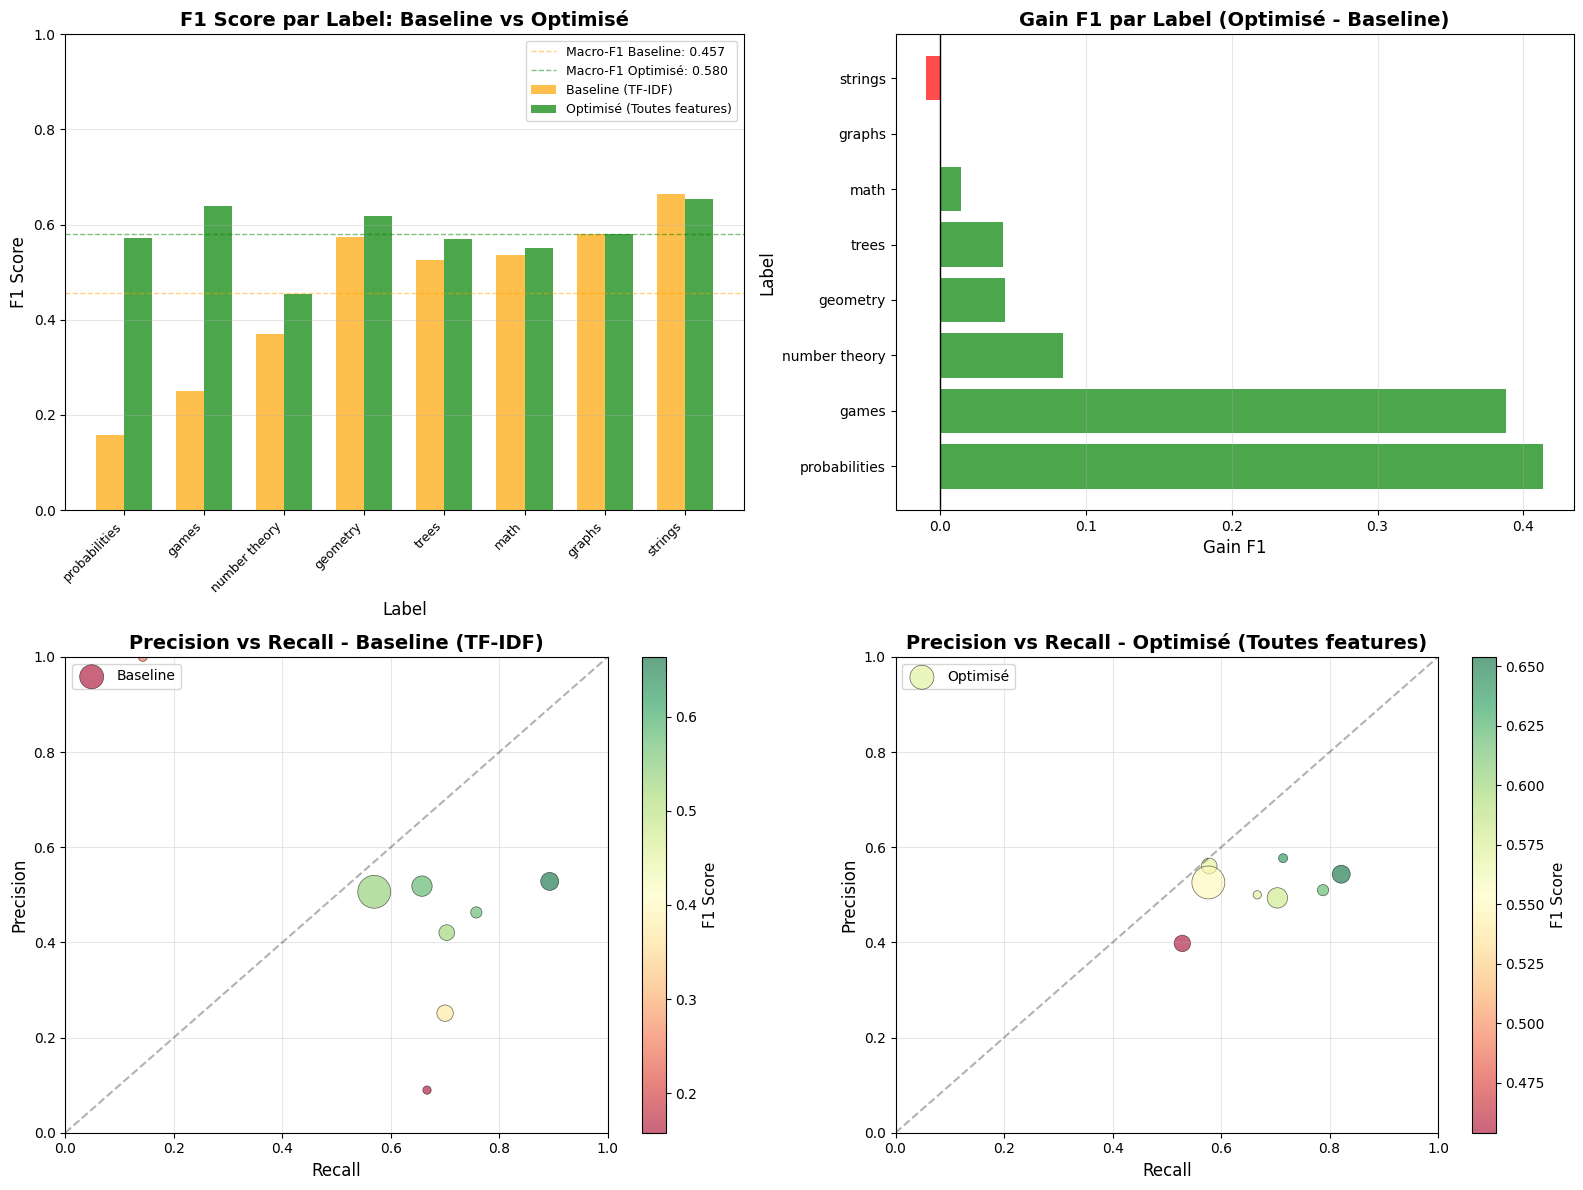

✅ Visualisations générées


In [37]:
# ============================================================================
# VISUALISATIONS - BASELINE vs OPTIMISÉ
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("GÉNÉRATION DES VISUALISATIONS")
print("="*80)

# On suppose que comparison_per_label a été calculé dans la cellule précédente

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: F1 Score par label - Baseline vs Optimisé
ax1 = axes[0, 0]
x = np.arange(len(comparison_per_label))
width = 0.35
ax1.bar(x - width/2, comparison_per_label["F1_Baseline"], width,
        label="Baseline (TF-IDF)", alpha=0.7, color="orange")
ax1.bar(x + width/2, comparison_per_label["F1_Optimized"], width,
        label="Optimisé (Toutes features)", alpha=0.7, color="green")
ax1.axhline(y=macro_f1_test_baseline, color="orange", linestyle="--", linewidth=1, alpha=0.5,
            label=f"Macro-F1 Baseline: {macro_f1_test_baseline:.3f}")
ax1.axhline(y=macro_f1_test_optimized, color="green", linestyle="--", linewidth=1, alpha=0.5,
            label=f"Macro-F1 Optimisé: {macro_f1_test_optimized:.3f}")
ax1.set_xlabel("Label", fontsize=12)
ax1.set_ylabel("F1 Score", fontsize=12)
ax1.set_title("F1 Score par Label: Baseline vs Optimisé", fontsize=14, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels([l[:15] for l in comparison_per_label["Label"]], rotation=45, ha="right", fontsize=9)
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)
ax1.set_ylim([0, 1])

# Plot 2: Gain F1 par label
ax2 = axes[0, 1]
colors_gain = ["green" if g > 0 else "red" for g in comparison_per_label["Gain_F1"]]
ax2.barh(comparison_per_label["Label"], comparison_per_label["Gain_F1"],
         color=colors_gain, alpha=0.7)
ax2.axvline(x=0, color="black", linestyle="-", linewidth=1)
ax2.set_xlabel("Gain F1", fontsize=12)
ax2.set_ylabel("Label", fontsize=12)
ax2.set_title("Gain F1 par Label (Optimisé - Baseline)", fontsize=14, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

# Plot 3: Precision vs Recall - Baseline
ax3 = axes[1, 0]
scatter1 = ax3.scatter(
    comparison_per_label["Rec_Baseline"],
    comparison_per_label["Prec_Baseline"],
    c=comparison_per_label["F1_Baseline"],
    s=comparison_per_label["Support"] * 2,
    alpha=0.6,
    cmap="RdYlGn",
    edgecolors="black",
    linewidth=0.5,
    label="Baseline",
)
ax3.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax3.set_xlabel("Recall", fontsize=12)
ax3.set_ylabel("Precision", fontsize=12)
ax3.set_title("Precision vs Recall - Baseline (TF-IDF)", fontsize=14, fontweight="bold")
ax3.legend()
ax3.grid(alpha=0.3)
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1])
cbar1 = plt.colorbar(scatter1, ax=ax3)
cbar1.set_label("F1 Score", fontsize=11)

# Plot 4: Precision vs Recall - Optimisé
ax4 = axes[1, 1]
scatter2 = ax4.scatter(
    comparison_per_label["Rec_Optimized"],
    comparison_per_label["Prec_Optimized"],
    c=comparison_per_label["F1_Optimized"],
    s=comparison_per_label["Support"] * 2,
    alpha=0.6,
    cmap="RdYlGn",
    edgecolors="black",
    linewidth=0.5,
    label="Optimisé",
)
ax4.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax4.set_xlabel("Recall", fontsize=12)
ax4.set_ylabel("Precision", fontsize=12)
ax4.set_title("Precision vs Recall - Optimisé (Toutes features)", fontsize=14, fontweight="bold")
ax4.legend()
ax4.grid(alpha=0.3)
ax4.set_xlim([0, 1])
ax4.set_ylim([0, 1])
cbar2 = plt.colorbar(scatter2, ax=ax4)
cbar2.set_label("F1 Score", fontsize=11)

plt.tight_layout()
plt.show()

print("✅ Visualisations générées")
print("="*80)

In [38]:
# ============================================================================
# RÉSUMÉ FINAL - BASELINE vs OPTIMISÉ
# ============================================================================

print("="*80)
print("RÉSUMÉ FINAL - BASELINE vs MODÈLE OPTIMISÉ")
print("="*80)

# S'assurer que comparison_per_label existe (le recalculer si nécessaire)
try:
    comparison_per_label
except NameError:
    f1_per_label_baseline = f1_score(y_test, y_test_pred_baseline, average=None)
    f1_per_label_optimized = f1_score(y_test, y_test_pred_optimized, average=None)
    precision_per_label_baseline = precision_score(y_test, y_test_pred_baseline, average=None, zero_division=0)
    precision_per_label_optimized = precision_score(y_test, y_test_pred_optimized, average=None, zero_division=0)
    recall_per_label_baseline = recall_score(y_test, y_test_pred_baseline, average=None, zero_division=0)
    recall_per_label_optimized = recall_score(y_test, y_test_pred_optimized, average=None, zero_division=0)

    comparison_per_label = pd.DataFrame({
        "Label": [col.replace("target_", "") for col in target_columns],
        "F1_Baseline": f1_per_label_baseline,
        "F1_Optimized": f1_per_label_optimized,
        "Gain_F1": f1_per_label_optimized - f1_per_label_baseline,
        "Prec_Baseline": precision_per_label_baseline,
        "Prec_Optimized": precision_per_label_optimized,
        "Rec_Baseline": recall_per_label_baseline,
        "Rec_Optimized": recall_per_label_optimized,
        "Support": y_test.sum(axis=0),
    })

print("\n### MODÈLE BASELINE (TF-IDF UNIQUEMENT) ###")
print(f"  Type:                               OneVsRestClassifier(LogisticRegression)")
print(f"  Features:                           TF-IDF uniquement ({X_tfidf_test.shape[1]:,} features)")
print(f"  Paramètres:")
print(f"    - C=1.0")
print(f"    - solver='saga'")
print(f"    - class_weight='balanced'")

print(f"\n  PERFORMANCES (TEST):")
print(f"    Micro-F1:                         {micro_f1_test_baseline:>8.4f}")
print(f"    Macro-F1:                         {macro_f1_test_baseline:>8.4f}")
print(f"    Micro-Precision:                  {micro_prec_test_baseline:>8.4f}")
print(f"    Micro-Recall:                     {micro_rec_test_baseline:>8.4f}")
print(f"    Hamming Loss:                     {hamming_test_baseline:>8.4f}")

print("\n### MODÈLE OPTIMISÉ (TOUTES FEATURES) ###")
print(f"  Type:                               OneVsRestClassifier(LogisticRegression)")
print(f"  Features:                           Toutes features ({X_test_logreg.shape[1]:,} features)")
print(f"    - TF-IDF:                         {X_tfidf_test.shape[1]:,}")
print(f"    - Embeddings:                     {embeddings_test.shape[1]:,}")
print(f"    - Denses (normalisées):           {X_dense_test.shape[1]:,}")
print(f"  Meilleurs paramètres:")
for param, value in best_params_logreg.items():
    print(f"    - {param}: {value}")

print(f"\n  PERFORMANCES (TEST):")
print(f"    Micro-F1:                         {micro_f1_test_optimized:>8.4f}")
print(f"    Macro-F1:                         {macro_f1_test_optimized:>8.4f}")
print(f"    Micro-Precision:                  {micro_prec_test_optimized:>8.4f}")
print(f"    Micro-Recall:                     {micro_rec_test_optimized:>8.4f}")
print(f"    Hamming Loss:                     {hamming_test_optimized:>8.4f}")

print("\n### GAINS ###")
print(f"  Micro-F1:                           {gain_micro_f1:>+8.2f}%")
print(f"  Macro-F1:                           {gain_macro_f1:>+8.2f}%")
print(f"  Labels améliorés:                   {(comparison_per_label['Gain_F1'] > 0).sum()} / {len(comparison_per_label)}")
print(f"  Meilleur gain:                      {comparison_per_label.loc[comparison_per_label['Gain_F1'].idxmax(), 'Label']} ({comparison_per_label['Gain_F1'].max():+.4f})")
print(f"  Moins bon gain:                      {comparison_per_label.loc[comparison_per_label['Gain_F1'].idxmin(), 'Label']} ({comparison_per_label['Gain_F1'].min():+.4f})")

print("\n" + "="*80)
print("✅ ANALYSE TERMINÉE")
print("="*80)

RÉSUMÉ FINAL - BASELINE vs MODÈLE OPTIMISÉ

### MODÈLE BASELINE (TF-IDF UNIQUEMENT) ###
  Type:                               OneVsRestClassifier(LogisticRegression)
  Features:                           TF-IDF uniquement (5,000 features)
  Paramètres:
    - C=1.0
    - solver='saga'
    - class_weight='balanced'

  PERFORMANCES (TEST):
    Micro-F1:                           0.4980
    Macro-F1:                           0.4573
    Micro-Precision:                    0.4044
    Micro-Recall:                       0.6480
    Hamming Loss:                       0.1114

### MODÈLE OPTIMISÉ (TOUTES FEATURES) ###
  Type:                               OneVsRestClassifier(LogisticRegression)
  Features:                           Toutes features (5,424 features)
    - TF-IDF:                         5,000
    - Embeddings:                     384
    - Denses (normalisées):           40
  Meilleurs paramètres:
    - estimator__C: 2
    - estimator__class_weight: balanced
    - estimator__pena

## 11. Autres Analyses

11.1 Importance des features par bloc (TF-IDF / Embeddings / Denses)
  TF-IDF features :   5000
  Embeddings dims :   384
  Dense features  :   40
  Total features  :   5424

Norme L2 moyenne des coefficients par bloc :
  TF-IDF   : 0.8926
  Embed.   : 2.0198
  Denses   : 0.5513


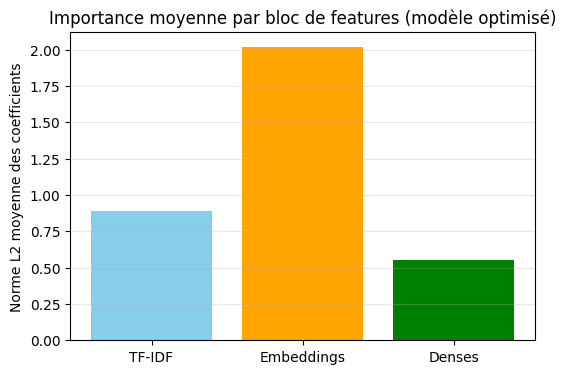

In [40]:
# 11.1 Importance des features par bloc pour le modèle optimisé (LogReg toutes features)

print("="*80)
print("11.1 Importance des features par bloc (TF-IDF / Embeddings / Denses)")
print("="*80)

# Dimensions des blocs
n_tfidf = X_tfidf_test.shape[1]
n_emb = embeddings_test.shape[1]
n_dense = X_dense_test.shape[1]

print(f"  TF-IDF features :   {n_tfidf}")
print(f"  Embeddings dims :   {n_emb}")
print(f"  Dense features  :   {n_dense}")
print(f"  Total features  :   {n_tfidf + n_emb + n_dense}")

# Coefficients de la LogisticRegression (shape: n_labels x n_features)
logreg = best_model_logreg.estimators_[0].__class__  # juste pour info
coefs = best_model_logreg.estimators_[0].coef_
# Pour un OneVsRestClassifier(LogReg), chaque estimator_ a ses propres coef_;
# on les empile pour tous les labels
all_coefs = np.vstack([est.coef_ for est in best_model_logreg.estimators_])  # (n_labels, n_features)

# Norme L2 moyenne des coeffs par bloc
tfidf_coefs = all_coefs[:, :n_tfidf]
emb_coefs = all_coefs[:, n_tfidf:n_tfidf + n_emb]
dense_coefs = all_coefs[:, n_tfidf + n_emb:]

tfidf_norm = np.mean(np.linalg.norm(tfidf_coefs, axis=0))
emb_norm = np.mean(np.linalg.norm(emb_coefs, axis=0))
dense_norm = np.mean(np.linalg.norm(dense_coefs, axis=0))

print("\nNorme L2 moyenne des coefficients par bloc :")
print(f"  TF-IDF   : {tfidf_norm:.4f}")
print(f"  Embed.   : {emb_norm:.4f}")
print(f"  Denses   : {dense_norm:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(["TF-IDF", "Embeddings", "Denses"], [tfidf_norm, emb_norm, dense_norm], color=["skyblue", "orange", "green"])
plt.ylabel("Norme L2 moyenne des coefficients")
plt.title("Importance moyenne par bloc de features (modèle optimisé)")
plt.grid(axis="y", alpha=0.3)
plt.show()

11.2 Top features denses par label (coefficients LogReg)

Label: games
------------------------------------------------------------
  has_sum                             coef = -0.4873
  difficulty                          coef = +0.3682
  nb_latex_symbols                    coef = +0.3074
  latex_density                       coef = -0.2967
  prob_desc_description_translated_latex_ratio coef = -0.2967
  has_ldots                           coef = -0.2653
  has_in                              coef = -0.2564
  latex_symbols_density               coef = +0.2465
  has_cdot                            coef = +0.2461
  has_gcd                             coef = +0.2337

Label: geometry
------------------------------------------------------------
  prob_desc_description_translated_word_count coef = -0.9102
  prob_desc_description_translated_char_length coef = +0.8119
  nb_latex_blocks                     coef = -0.6050
  difficulty                          coef = +0.5526
  has_limits          

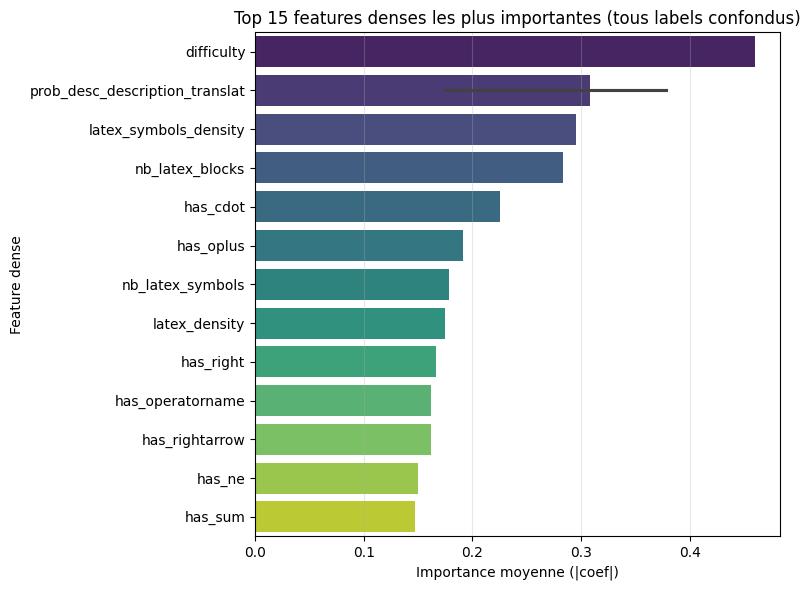

In [43]:
# 11.2 Top features denses les plus importantes par label

print("="*80)
print("11.2 Top features denses par label (coefficients LogReg)")
print("="*80)

dense_feature_names = features_numeriques + features_latex

n_labels = len(target_columns)
dense_importances = []

for j, est in enumerate(best_model_logreg.estimators_):
    label_name = target_columns[j].replace("target_", "")
    coefs_label = est.coef_.ravel()
    dense_coefs_label = coefs_label[n_tfidf + n_emb:]
    # importance = |coef|
    top_idx = np.argsort(np.abs(dense_coefs_label))[::-1][:10]
    top_feats = [(dense_feature_names[i], dense_coefs_label[i]) for i in top_idx]
    dense_importances.append((label_name, top_feats))

for label_name, top_feats in dense_importances:
    print(f"\nLabel: {label_name}")
    print("-" * 60)
    for feat, coef_val in top_feats:
        print(f"  {feat:<35s} coef = {coef_val:>+.4f}")

# Heatmap des importances absolues moyennes des features denses sur tous les labels
dense_coefs_abs_mean = np.mean(np.abs(dense_coefs), axis=0)
top_k = 15
top_idx_global = np.argsort(dense_coefs_abs_mean)[::-1][:top_k]
top_dense_names = [dense_feature_names[i] for i in top_idx_global]

plt.figure(figsize=(8, 6))
sns.barplot(
    x=dense_coefs_abs_mean[top_idx_global],
    y=[name[:30] for name in top_dense_names],
    orient="h",
    palette="viridis",
)
plt.xlabel("Importance moyenne (|coef|)")
plt.ylabel("Feature dense")
plt.title(f"Top {top_k} features denses les plus importantes (tous labels confondus)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

11.3 Corrélation features denses vs probas prédites (TEST)

Top 5 features les plus corrélées (moyenne absolue sur les labels) :
  difficulty                          |corr| moyen = 0.2026
  prob_desc_description_translated_word_count |corr| moyen = 0.1456
  prob_desc_description_translated_char_length |corr| moyen = 0.1410
  latex_symbols_density               |corr| moyen = 0.1372
  prob_desc_description_translated_numeric_ratio |corr| moyen = 0.1342


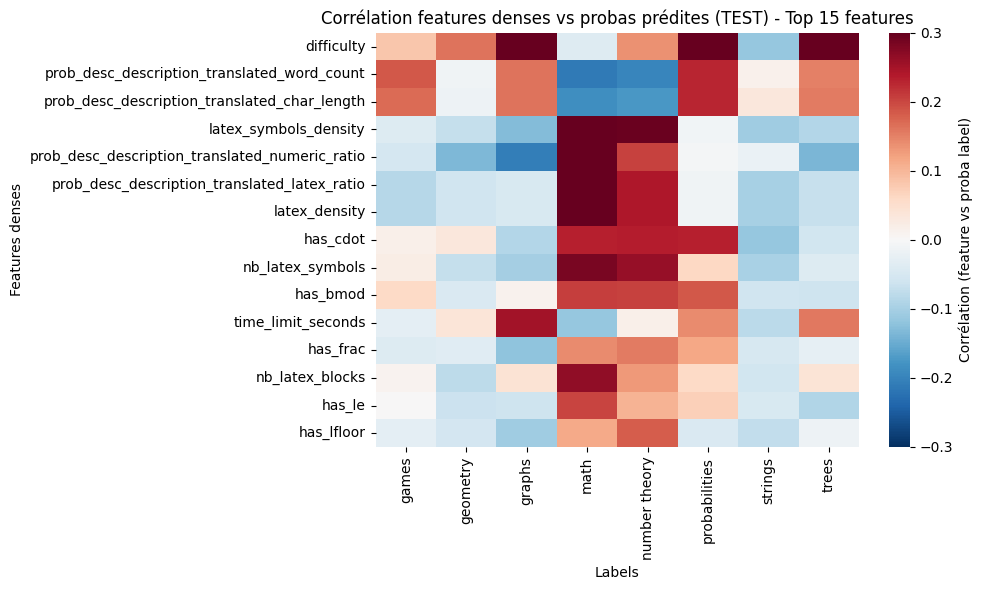

In [44]:
# 11.3 Corrélation features denses vs probas prédites (TEST)

print("="*80)
print("11.3 Corrélation features denses vs probas prédites (TEST)")
print("="*80)

# Probabilités prédites (modèle optimisé)
y_test_proba_opt = best_model_logreg.predict_proba(X_test_logreg)
if isinstance(y_test_proba_opt, list):
    # cas OneVsRest avec liste de tableaux
    y_test_proba_opt = np.column_stack([p[:, 1] for p in y_test_proba_opt])

X_dense_test_arr = np.asarray(X_dense_test)

corr_mat = []
for i_feat in range(n_dense):
    feat_vals = X_dense_test_arr[:, i_feat]
    row_corr = []
    for j in range(y_test_proba_opt.shape[1]):
        proba_label = y_test_proba_opt[:, j]
        if np.std(feat_vals) == 0 or np.std(proba_label) == 0:
            corr = 0.0
        else:
            corr = np.corrcoef(feat_vals, proba_label)[0, 1]
        row_corr.append(corr)
    corr_mat.append(row_corr)

corr_df = pd.DataFrame(
    corr_mat,
    index=dense_feature_names,
    columns=[col.replace("target_", "") for col in target_columns],
)

print("\nTop 5 features les plus corrélées (moyenne absolue sur les labels) :")
mean_abs_corr = corr_df.abs().mean(axis=1).sort_values(ascending=False)
for feat, val in mean_abs_corr.head(5).items():
    print(f"  {feat:<35s} |corr| moyen = {val:>6.4f}")

# Heatmap sur les 15 features denses les plus corrélées
top_15_feats = mean_abs_corr.head(15).index.tolist()
corr_subset = corr_df.loc[top_15_feats]

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_subset,
    cmap="RdBu_r",
    center=0,
    vmin=-0.3,
    vmax=0.3,
    cbar_kws={"label": "Corrélation (feature vs proba label)"},
)
plt.title("Corrélation features denses vs probas prédites (TEST) - Top 15 features")
plt.xlabel("Labels")
plt.ylabel("Features denses")
plt.tight_layout()
plt.show()